In [2]:
import pandas as pd

df = pd.read_csv('../data/cars_dataframe.csv')
df.shape

(101896, 15)

In [3]:
df.head()

,Brand,Model,Year,Condition,Mileage,Gearbox,Fiscal Power,Fuel,Equipment,Number of Doors,Origin,First Owner,Location,Sector,Price
0,Volkswagen,Polo,1997,Good,200 000 - 249 999,Manual,8 CV,Diesel,"['Leather Seats', 'CD/MP3/Bluetooth']",NaN,NaN,NaN,Tétouan,City Center,27000.0
1,Dacia,Sandero,2012,Very Good,180 000 - 189 999,Manual,6 CV,Diesel,"['Rear Camera', 'Electric Windows']",5.0,WW in Morocco,No,Temara,City Center,69000.0
2,Volkswagen,Polo,2004,Fair,300 000 - 349 999,Manual,8 CV,Diesel,"['Alloy Wheels', 'Electric Windows']",5.0,WW in Morocco,No,Safi,Chenguite,45000.0
3,Bentley,Continental gtc,2009,Excellent,45 000 - 49 999,Automatic,34 CV,Petrol,"['Rear Camera', 'Electric Windows']",3.0,Customs-cleared car,Yes,Casablanca,Aïn Chock,720000.0
4,mini,cooper,2013,Excellent,85 000 - 89 999,Automatic,8 CV,Diesel,"['Airbags', 'CD/MP3/Bluetooth', 'Rear Camera',...",5.0,WW in Morocco,No,Fès,Agdal,128000.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101896 entries, 0 to 101895
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Brand            101895 non-null  object 
 1   Model            101895 non-null  object 
 2   Year             101896 non-null  object 
 3   Condition        98313 non-null   object 
 4   Mileage          101895 non-null  object 
 5   Gearbox          101896 non-null  object 
 6   Fiscal Power     101616 non-null  object 
 7   Fuel             101896 non-null  object 
 8   Equipment        101896 non-null  object 
 9   Number of Doors  90481 non-null   float64
 10  Origin           89921 non-null   object 
 11  First Owner      87196 non-null   object 
 12  Location         101896 non-null  object 
 13  Sector           101650 non-null  object 
 14  Price            76413 non-null   float64
dtypes: float64(2), object(13)
memory usage: 11.7+ MB


In [5]:
df.isnull().sum().sort_values(ascending=False)

Price              25483
First Owner        14700
Origin             11975
Number of Doors    11415
Condition           3583
Fiscal Power         280
Sector               246
Brand                  1
Mileage                1
Model                  1
Year                   0
Gearbox                0
Equipment              0
Fuel                   0
Location               0
dtype: int64

**Noticed:**: 25,483 missing values for "Price" column out of 101,896 rows means 25% of the dataset has no price label.
In a supervised regression problem, rows without a label are completely useless for training

**Noticed:** Year and Mileage: both are object (string), not numeric.
What I would do is to investigate Year and Mileage dtypes before touching anything else; this could reveal more cleaning work than the nulls did.

In [7]:
df['Year'].unique()[:20]

array(['1997', '2012', '2004', '2009', '2013', '2020', '2015', '2018',
       '2000', '2016', '1998', '2019', '2007', '2003', '1993', '2023',
       '2021', '2010', '2011', '2022'], dtype=object)

In [10]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Year'].isnull().sum()

np.int64(307)

**Approach for "Year" null count:** 307 out of 101,896 is 0.3% , negligible. This is such a small fraction, which means the simplest and most efficient move is to drop them rather than impute. We don't lose meaningful sample size, and there's no good way to "guess" a car's year anyway.

In [ ]:
df['Mileage'].unique()[:20]

array(['200 000 - 249 999', '180 000 - 189 999', '300 000 - 349 999',
       '45 000 - 49 999', '85 000 - 89 999', '0 - 4 999',
       '30 000 - 34 999', '25 000 - 29 999', '140 000 - 149 999',
       '150 000 - 159 999', '100 000 - 109 999', '15 000 - 19 999',
       '250 000 - 299 999', '60 000 - 64 999', '5 000 - 9 999',
       '40 000 - 44 999', '160 000 - 169 999', '55 000 - 59 999',
       '110 000 - 119 999', '10 000 - 14 999'], dtype=object)

**Noticed:** Mileage isn't a precise number like 85342, it's a bucketed range, like '85 000 - 89 999'.

In [12]:
df['Mileage'].apply(lambda v: isinstance(v, str) and '-' not in v).sum()

np.int64(933)

In [13]:
df.loc[df['Mileage'].apply(lambda v: isinstance(v, str) and '-' not in v), 'Mileage'].unique()[:20]

array(['Plus de 500 000'], dtype=object)

**Approach:** Convert each bracket to its midpoint as a numeric proxy. '85 000 - 89 999' → 87499.5. This gives us a continuous numeric feature instead of a categorical one, which often helps tree-based models used in our case (LightGBM, XGBoost) capture smoother relationships between mileage and price. 

In [16]:
def mileage_to_midpoint(value):
    if pd.isnull(value):
        return None
    value = value.replace(' ', '')
    if 'Plusde' in value:
        return 550000  # reasonable midpoint estimate for an open-ended 500k+ bracket
    low, high = value.split('-')
    return (int(low) + int(high)) / 2

df['Mileage_numeric'] = df['Mileage'].apply(mileage_to_midpoint)
df[['Mileage', 'Mileage_numeric']].head()

,Mileage,Mileage_numeric
0,200 000 - 249 999,224999.5
1,180 000 - 189 999,184999.5
2,300 000 - 349 999,324999.5
3,45 000 - 49 999,47499.5
4,85 000 - 89 999,87499.5


In [18]:
df['Mileage_numeric'].isnull().sum()

np.int64(1)

In [19]:
df['Mileage_numeric'].describe()

count    101895.000000
mean     132749.835802
std      103691.775325
min        2499.500000
25%       47499.500000
50%      124999.500000
75%      194999.500000
max      550000.000000
Name: Mileage_numeric, dtype: float64

**Approach:** Handle the drops of Price, Year and Mileage_numeric together

In [20]:
before = len(df)

df = df.dropna(subset=['Price', 'Year', 'Mileage_numeric'])

after = len(df)
print(f"Dropped {before - after} rows ({(before - after) / before * 100:.1f}%)")
print(f"Remaining: {after} rows")

Dropped 25671 rows (25.2%)
Remaining: 76225 rows


In [23]:
for col in ['First Owner', 'Origin', 'Condition', 'Number of Doors', 'Fiscal Power', 'Sector']:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- First Owner ---
First Owner
No     42872
Yes    23893
NaN     9460
Name: count, dtype: int64

--- Origin ---
Origin
WW in Morocco                  50000
Customs-cleared car            13744
NaN                             8429
Imported New                    3520
Car not yet customs-cleared      532
Name: count, dtype: int64

--- Condition ---
Condition
Excellent    32151
Very Good    27223
Good         10294
New           2682
NaN           2164
Fair          1593
Damaged         67
For Parts       51
Name: count, dtype: int64

--- Number of Doors ---
Number of Doors
5.0    64420
NaN     7429
3.0     4376
Name: count, dtype: int64

--- Fiscal Power ---
Fiscal Power
6 CV             29032
8 CV             20417
7 CV              9857
9 CV              4838
5 CV              2983
12 CV             2719
10 CV             2292
11 CV             1679
4 CV               965
13 CV              218
NaN                209
Plus de 41 CV      207
14 CV              154
17 CV              120

In [24]:
df['First Owner'] = df['First Owner'].fillna('Unknown')

In [25]:
df['Origin'] = df['Origin'].fillna('Unknown')

In [26]:
df['Condition'] = df['Condition'].fillna('Unknown')

In [27]:
df['Number of Doors'] = df['Number of Doors'].fillna(df['Number of Doors'].mode()[0])

In [28]:
df['Fiscal Power'].unique()

array(['8 CV', '6 CV', '34 CV', '7 CV', '4 CV', '11 CV', '9 CV', '10 CV',
       '12 CV', '14 CV', '5 CV', 'Plus de 41 CV', '13 CV', '17 CV',
       '16 CV', '22 CV', '15 CV', '19 CV', '30 CV', '24 CV', '23 CV',
       '20 CV', '38 CV', '35 CV', '18 CV', '29 CV', '37 CV', '31 CV',
       '28 CV', '21 CV', '32 CV', '27 CV', '36 CV', '39 CV', nan, '33 CV',
       '41 CV', '26 CV', '25 CV', '40 CV'], dtype=object)

**Approach:** Handle the problem of Fiscal Power the same way as We did with Mileage

In [31]:
def fiscal_power_to_numeric(value):
    if pd.isnull(value):
        return None
    if 'Plus de' in value:
        return 45  # representative estimate for the open-ended "more than 41 CV" bracket
    return int(value.replace(' CV', ''))

df['Fiscal_Power_numeric'] = df['Fiscal Power'].apply(fiscal_power_to_numeric)
df['Fiscal_Power_numeric'].isnull().sum()

np.int64(209)

In [34]:
df['Fiscal_Power_numeric'] = df['Fiscal_Power_numeric'].fillna(df['Fiscal_Power_numeric'].mode()[0])

In [36]:
df['Fiscal_Power_numeric'].isnull().sum()

np.int64(0)

In [39]:
df = df.drop(columns=['Mileage', 'Fiscal Power'])

In [40]:
df.isnull().sum().sort_values(ascending=False)

Sector                  175
Model                     0
Brand                     0
Condition                 0
Gearbox                   0
Fuel                      0
Year                      0
Equipment                 0
Number of Doors           0
First Owner               0
Origin                    0
Location                  0
Price                     0
Mileage_numeric           0
Fiscal_Power_numeric      0
dtype: int64

In [41]:
df['Sector'] = df['Sector'].fillna('Unknown')

In [51]:
df['Location'].nunique()

380

In [49]:
df = df.drop(columns=['Sector'])

In [53]:
df['Location'].value_counts().head(20)

Location
Casablanca     20606
Tanger          5311
Marrakech       5182
Rabat           5057
Agadir          4148
Fès             3909
Meknès          2821
Salé            2668
Kénitra         2604
Temara          1901
El Jadida       1893
Tétouan         1517
Mohammedia      1330
Oujda           1149
Nador            929
Safi             783
Béni Mellal      772
Laâyoune         719
Khouribga        696
Berrechid        605
Name: count, dtype: int64

In [61]:
df['Location'].value_counts().tail(65)

Location
El Menzeh          1
Bhalil             1
Loudaya            1
مراكش              1
Naima              1
                  ..
الناظور            1
Moulay Abdallah    1
Sidi Jaber         1
Ouislane           1
Itzer              1
Name: count, Length: 65, dtype: int64

In [ ]:
arabic_to_french = {
    'فاس': 'Fès',
    'القنيطرة': 'Kénitra',
    'المحمدية': 'Mohammedia',
    'الناظور': 'Nador',
    'الرباط': 'Rabat',
    'الجديدة': 'El Jadida',
    'مراكش': 'Marrakech'
}

df['Location'] = df['Location'].replace(arabic_to_french)

In [63]:
top_cities = df['Location'].value_counts().nlargest(20).index
df['Location_grouped'] = df['Location'].where(df['Location'].isin(top_cities), 'Other')
df['Location_grouped'].value_counts()

Location_grouped
Casablanca     20606
Other          11618
Tanger          5311
Marrakech       5183
Rabat           5058
Agadir          4148
Fès             3910
Meknès          2821
Salé            2668
Kénitra         2605
Temara          1901
El Jadida       1894
Tétouan         1517
Mohammedia      1331
Oujda           1149
Nador            930
Safi             783
Béni Mellal      772
Laâyoune         719
Khouribga        696
Berrechid        605
Name: count, dtype: int64

In [64]:
df = df.drop(columns=['Location'])

**Feature Engineering**

In [65]:
df['Year'].max()

np.float64(2024.0)

In [66]:
df['car_age'] = 2024 - df['Year']
df['mileage_per_year'] = df['Mileage_numeric'] / df['car_age'].replace(0, 1)

In [67]:
df[['car_age', 'mileage_per_year']].describe()

,car_age,mileage_per_year
count,76225.000000,76225.000000
mean,12.254090,15549.887724
std,8.504074,12946.135905
min,0.000000,58.127907
25%,6.000000,8157.868421
50%,10.000000,14999.928571
75%,17.000000,20833.250000
max,43.000000,550000.000000


In [68]:
df[df['mileage_per_year'] > 100000][['Year', 'car_age', 'Mileage_numeric', 'mileage_per_year']].head(10)

,Year,car_age,Mileage_numeric,mileage_per_year
173,2019.0,5.0,550000.0,110000.00
1041,2024.0,0.0,184999.5,184999.50
1195,2024.0,0.0,374999.5,374999.50
1555,2023.0,1.0,174999.5,174999.50
2191,2022.0,2.0,224999.5,112499.75
2469,2023.0,1.0,114999.5,114999.50
2668,2024.0,0.0,134999.5,134999.50
3830,2024.0,0.0,164999.5,164999.50
8726,2024.0,0.0,154999.5,154999.50
12265,2019.0,5.0,550000.0,110000.00


In [69]:
len(df[df['mileage_per_year'] > 100000])

81

In [70]:
cap_value = df['mileage_per_year'].quantile(0.99)
print(f"99th percentile cap: {cap_value:.0f}")

df['mileage_per_year'] = df['mileage_per_year'].clip(upper=cap_value)
df['mileage_per_year'].describe()

99th percentile cap: 50000


count    76225.000000
mean     15281.417853
std      10423.768661
min         58.127907
25%       8157.868421
50%      14999.928571
75%      20833.250000
max      50000.000000
Name: mileage_per_year, dtype: float64

In [71]:
df.columns.tolist()

['Brand',
 'Model',
 'Year',
 'Condition',
 'Gearbox',
 'Fuel',
 'Equipment',
 'Number of Doors',
 'Origin',
 'First Owner',
 'Price',
 'Mileage_numeric',
 'Fiscal_Power_numeric',
 'Location_grouped',
 'car_age',
 'mileage_per_year']

In [ ]:
df['Equipment'].nunique()

9424

In [74]:
df['Equipment'].unique()[:10]

array(["['Leather Seats', 'CD/MP3/Bluetooth']",
       "['Rear Camera', 'Electric Windows']",
       "['Alloy Wheels', 'Electric Windows']",
       "['Airbags', 'CD/MP3/Bluetooth', 'Rear Camera', 'Air Conditioning', 'ESP', 'Alloy Wheels', 'Speed Limiter', 'Onboard Computer', 'Parking Sensors', 'Cruise Control', 'Leather Seats', 'Navigation System/GPS', 'Central Locking', 'Electric Windows']",
       "['Electric Windows', 'CD/MP3/Bluetooth']",
       "['CD/MP3/Bluetooth', 'Rear Camera', 'Air Conditioning', 'Speed Limiter', 'Parking Sensors', 'Leather Seats', 'Electric Windows']",
       "['CD/MP3/Bluetooth', 'Leather Seats']",
       "['ABS', 'CD/MP3/Bluetooth', 'Rear Camera', 'Air Conditioning', 'ESP', 'Speed Limiter', 'Cruise Control', 'Leather Seats', 'Navigation System/GPS', 'Central Locking', 'Electric Windows']",
       "['Leather Seats', 'Electric Windows']",
       "['ABS', 'CD/MP3/Bluetooth', 'Rear Camera', 'Air Conditioning', 'Parking Sensors', 'Leather Seats', 'Electric Windo

In [75]:
df['Brand'].nunique()

73

In [76]:
df['Model'].nunique()

954

In [77]:
import ast

# Convert the string representation of a list into an actual Python list
df['Equipment_list'] = df['Equipment'].apply(ast.literal_eval)

# Find every unique equipment item across the whole dataset
all_equipment = set()
for items in df['Equipment_list']:
    all_equipment.update(items)

print(len(all_equipment))
print(sorted(all_equipment))

16
['ABS', 'Air Conditioning', 'Airbags', 'Alloy Wheels', 'CD/MP3/Bluetooth', 'Central Locking', 'Cruise Control', 'ESP', 'Electric Windows', 'Leather Seats', 'Navigation System/GPS', 'Onboard Computer', 'Parking Sensors', 'Rear Camera', 'Speed Limiter', 'Sunroof']


In [78]:
for item in sorted(all_equipment):
    col_name = 'has_' + item.replace('/', '_').replace(' ', '_')
    df[col_name] = df['Equipment_list'].apply(lambda lst: 1 if item in lst else 0)

In [79]:
equipment_cols = [c for c in df.columns if c.startswith('has_')]
df[equipment_cols].sum().sort_values(ascending=False)

has_Electric_Windows         46369
has_CD_MP3_Bluetooth         42916
has_Alloy_Wheels             40624
has_Air_Conditioning         36077
has_Central_Locking          33527
has_Airbags                  33494
has_Rear_Camera              30294
has_ABS                      30243
has_Speed_Limiter            26011
has_Leather_Seats            25941
has_Cruise_Control           25860
has_Parking_Sensors          24877
has_Onboard_Computer         23831
has_ESP                      22938
has_Navigation_System_GPS    20185
has_Sunroof                   8807
dtype: int64

In [80]:
df = df.drop(columns=['Equipment', 'Equipment_list'])

In [81]:
df['Model'].value_counts().head(30)

Model
Clio                  2787
Logan                 2405
Kangoo                1477
Tiguan                1464
220                   1341
Duster                1238
Focus                 1170
Dokker                1155
Fiesta                1079
208                    913
Touareg                868
Tucson                 836
Picanto                812
Classe C               801
Polo                   799
Passat                 785
Palio                  780
19                     778
Accent                 766
Qashqai                764
Berlingo               751
500                    725
GOLF 7                 720
Kuga                   666
Uno                    651
Partner                643
sandero_stepway        642
Range Rover Evoque     631
Astra                  623
C3                     604
Name: count, dtype: int64

In [85]:
df['Model'].value_counts().tail(20)

Model
FJ CRUISER            1
407 COUPE             1
mg5                   1
560                   1
CAPRI                 1
MR                    1
RS4                   1
PRELUDE               1
Serie 8 gran coupé    1
mg4                   1
Yukon                 1
COBRA                 1
Brougham              1
MOVANO                1
Classe M              1
xuv_500               1
Rogue                 1
73                    1
Glory 500             1
boxster_s             1
Name: count, dtype: int64

In [89]:
df['Model'] = df['Model'].str.replace('_', ' ').str.title()
df['Model'].nunique()

953

In [92]:
top_models = df['Model'].value_counts().nlargest(40).index
df['Model_grouped'] = df['Model'].where(df['Model'].isin(top_models), 'Other')
df['Model_grouped'].value_counts().tail()

Model_grouped
206         524
Golf 4      516
Punto       510
308         500
Santa Fe    489
Name: count, dtype: int64

In [93]:
df = df.drop(columns=['Model'])

In [94]:
df.columns.tolist()

['Brand',
 'Year',
 'Condition',
 'Gearbox',
 'Fuel',
 'Number of Doors',
 'Origin',
 'First Owner',
 'Price',
 'Mileage_numeric',
 'Fiscal_Power_numeric',
 'Location_grouped',
 'car_age',
 'mileage_per_year',
 'has_ABS',
 'has_Air_Conditioning',
 'has_Airbags',
 'has_Alloy_Wheels',
 'has_CD_MP3_Bluetooth',
 'has_Central_Locking',
 'has_Cruise_Control',
 'has_ESP',
 'has_Electric_Windows',
 'has_Leather_Seats',
 'has_Navigation_System_GPS',
 'has_Onboard_Computer',
 'has_Parking_Sensors',
 'has_Rear_Camera',
 'has_Speed_Limiter',
 'has_Sunroof',
 'Model_grouped']

Defining X and y before splitting

In [95]:
X = df.drop(columns=['Price'])
y = df['Price']

y.describe()

count    7.622500e+04
mean     4.990145e+05
std      1.589577e+07
min      1.000000e+00
25%      6.000000e+04
50%      1.100000e+05
75%      1.700000e+05
max      1.600000e+09
Name: Price, dtype: float64

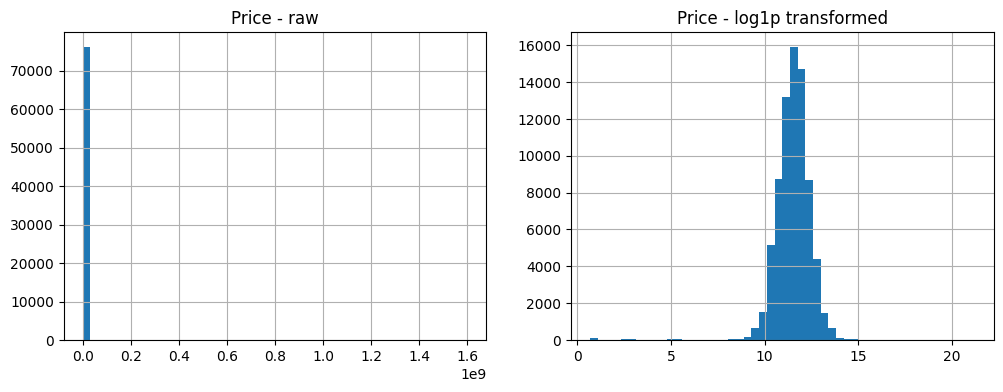

In [96]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y.hist(bins=50, ax=axes[0])
axes[0].set_title('Price - raw')

import numpy as np
np.log1p(y).hist(bins=50, ax=axes[1])
axes[1].set_title('Price - log1p transformed')

plt.show()

In [97]:
df['Price'].sort_values(ascending=False).head(30)

50882    1.600000e+09
45745    1.111111e+09
46362    1.111111e+09
32541    1.000005e+09
39353    9.000000e+08
27581    7.092381e+08
27269    7.034707e+08
33921    7.010579e+08
32184    6.821806e+08
43036    6.815692e+08
42552    6.747368e+08
76488    6.663399e+08
33020    6.617781e+08
86485    6.616765e+08
49229    6.615416e+08
55155    6.612803e+08
40456    6.612297e+08
87737    6.610495e+08
38404    6.603136e+08
33199    6.601712e+08
33695    6.482375e+08
28464    6.379646e+08
51481    6.356847e+08
28763    6.352626e+08
51526    6.302265e+08
33705    6.285487e+08
34986    6.250961e+08
52036    6.196500e+08
70337    6.188187e+08
87640    6.050538e+08
Name: Price, dtype: float64

In [98]:
df['Price'].sort_values(ascending=True).head(30)

58867    1.0
47505    1.0
57969    1.0
72744    1.0
72851    1.0
44383    1.0
27203    1.0
51867    1.0
26926    1.0
26890    1.0
33031    1.0
48908    1.0
46247    1.0
51696    1.0
29441    1.0
60150    1.0
30381    1.0
32701    1.0
44921    1.0
18264    1.0
45812    1.0
33974    1.0
33916    1.0
50763    1.0
30424    1.0
30294    1.0
60178    1.0
60215    1.0
39601    1.0
44255    1.0
Name: Price, dtype: float64

In [101]:
df['Price'].quantile([0.001, 0.005, 0.01, 0.02, 0.05])

0.001        1.0
0.005      160.6
0.010    10500.0
0.020    17000.0
0.050    27000.0
Name: Price, dtype: float64

In [100]:
df['Price'].quantile([0.95, 0.98, 0.99, 0.995, 0.999])

0.950    3.700000e+05
0.980    5.500000e+05
0.990    7.600000e+05
0.995    1.114533e+06
0.999    1.188800e+07
Name: Price, dtype: float64

In [102]:
before = len(df)

df = df[(df['Price'] >= 5000) & (df['Price'] <= 2000000)]

after = len(df)
print(f"Removed {before - after} rows ({(before - after) / before * 100:.2f}%)")
print(f"Remaining: {after} rows")

Removed 764 rows (1.00%)
Remaining: 75461 rows


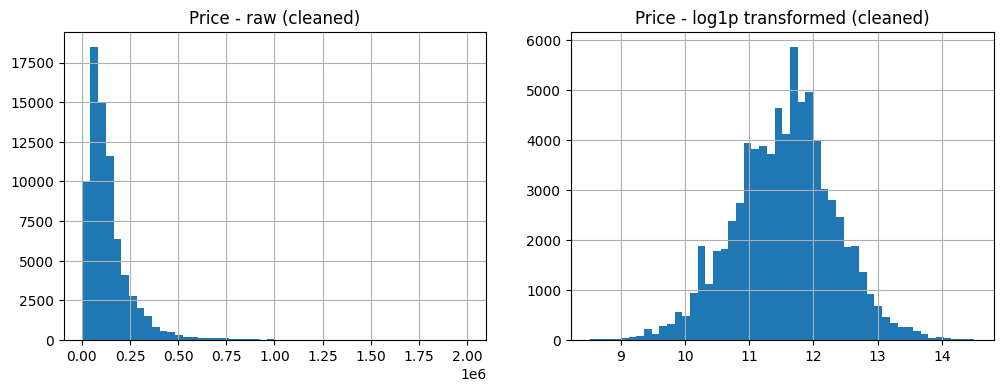

In [103]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['Price'].hist(bins=50, ax=axes[0])
axes[0].set_title('Price - raw (cleaned)')

np.log1p(df['Price']).hist(bins=50, ax=axes[1])
axes[1].set_title('Price - log1p transformed (cleaned)')

plt.show()

In [104]:
df['log_price'] = np.log1p(df['Price'])

In [108]:
df.to_csv('../data/cars_cleaned.csv', index=False)